In [1]:
# ─────────────────────────────────────────────
# 0 : Loading
# ─────────────────────────────────────────────

%reload_ext autoreload
%autoreload 2

In [2]:
# ─────────────────────────────────────────────
# 1.1 : Python Version
# ─────────────────────────────────────────────

import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


# ─────────────────────────────────────────────
# 1.2 : Librairies
# ─────────────────────────────────────────────

import pickle
import numpy as np
import polars as pl
import pyarrow.parquet as pq

from pathlib import Path
from matplotlib import pyplot as plt

from nucleo.io.reading import getting_main_file_with_verifications
from nucleo.io.plots_2D import plot_one_heatmap_from_df, plot_all_heatmaps
# plt.rcParams["font.size"] = 12

Python: /home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/bin/python
User site: /home/nicolas/.local/lib/python3.12/site-packages
Site-packages: ['/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/local/lib/python3.12/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/dist-packages']


In [3]:
# ─────────────────────────────────────────────
# 2.1 : Main file + Verification
# ─────────────────────────────────────────────

# Locating
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-07-17")
main_file_path = root / "ncl_output.parquet"

# Reading
data = pq.read_table(main_file_path)
df_polars = pl.DataFrame(data)

# Loading file + Filtering
df_main = getting_main_file_with_verifications(df_polars)
print('The df_polars containing the int and floats for all our simulations :\nTotal shape :',df_main.shape, '\nQuick print and shape :', df_main.head(5))

The df_polars containing the int and floats for all our simulations :
Total shape : (310200, 27) 
Quick print and shape : shape: (5, 27)
┌────────┬─────┬─────┬───────┬───┬────────────┬────────────┬──────────┬───────┐
│ land   ┆ s   ┆ l   ┆ bpmin ┆ … ┆ wf_std     ┆ vi_mean    ┆ vi_med   ┆ vi_mp │
│ ---    ┆ --- ┆ --- ┆ ---   ┆   ┆ ---        ┆ ---        ┆ ---      ┆ ---   │
│ str    ┆ i64 ┆ i64 ┆ i64   ┆   ┆ f64        ┆ f64        ┆ f64      ┆ f64   │
╞════════╪═════╪═════╪═══════╪═══╪════════════╪════════════╪══════════╪═══════╡
│ random ┆ 150 ┆ 10  ┆ 5     ┆ … ┆ 0.053763   ┆ 124.180853 ┆ 1.503016 ┆ 0.5   │
│ random ┆ 150 ┆ 10  ┆ 5     ┆ … ┆ 0.000238   ┆ 12.711737  ┆ 0.254544 ┆ 0.5   │
│ random ┆ 150 ┆ 10  ┆ 5     ┆ … ┆ 0.000241   ┆ 11.538787  ┆ 0.29071  ┆ 0.5   │
│ random ┆ 150 ┆ 10  ┆ 5     ┆ … ┆ 0.000237   ┆ 9.961928   ┆ 0.339291 ┆ 0.5   │
│ random ┆ 150 ┆ 10  ┆ 5     ┆ … ┆ 5.0562e-15 ┆ 8.184515   ┆ 0.368533 ┆ 0.5   │
└────────┴─────┴─────┴───────┴───┴────────────┴────────────┴───

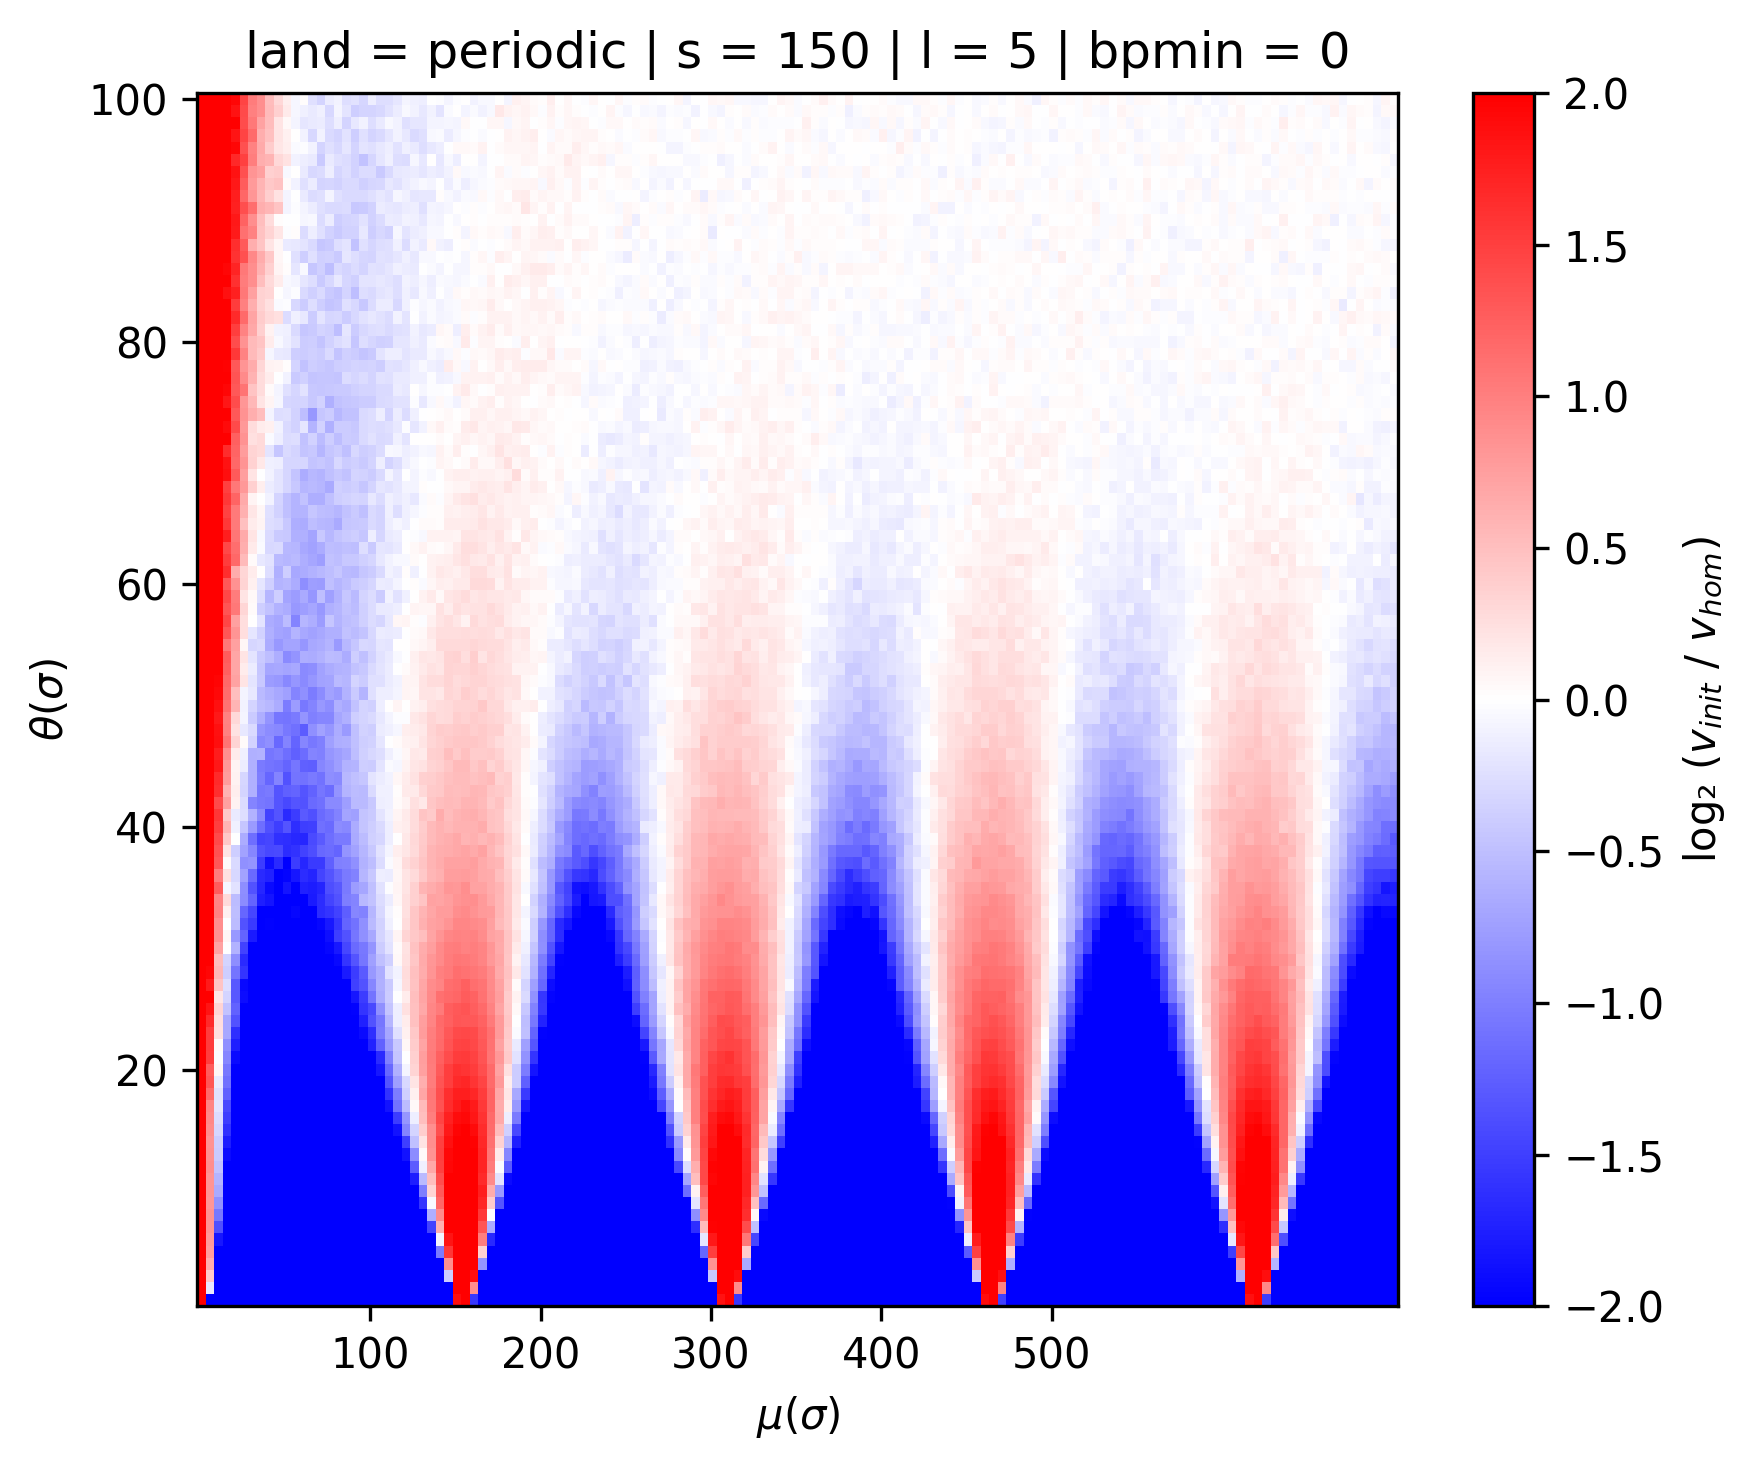

In [4]:
# ─────────────────────────────────────────────
# 2.2.1 : Heatmaps - Single
# ─────────────────────────────────────────────

heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=0,        # équivalent du `key` de l'ancien dict (premier idx = 0)
    speed_col="vf",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=False,
    title=True,
)
plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────────
# 2.2.2 : Heatmaps - Multi
# ─────────────────────────────────────────────

plot_all_heatmaps(
    speed_cols=["v_mean", "vf", "wf"],
    root=root,
    type_of_data="norm_th",
    plot_log2=True,
)

Plotting heatmaps: 100%|██████████| 20/20 [00:01<00:00, 12.30it/s]


(<Figure size 6400x32000 with 120 Axes>,
 array([[<Axes: title={'center': 'land = periodic | s = 150 | l = 5 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': 'land = periodic | s = 150 | l = 5 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': 'land = periodic | s = 150 | l = 5 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>],
        [<Axes: title={'center': 'land = periodic | s = 150 | l = 10 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': 'land = periodic | s = 150 | l = 10 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': 'land = periodic | s = 150 | l = 10 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>],
        [<Axes: title={'center': 'land = periodic | s = 150 | l = 15 | bpmin = 0'}, xlabel='$\\mu(\\sigma)$', ylabel='$\

# .